# **Course 2 End-of-course project: Exploratory data analysis**

In this activity, you will examine data provided and prepare it for analysis. You will also design a professional data visualization that tells a story, and will help data-driven decisions for business needs.

Please note that the Tableau visualization activity is optional, and will not affect your completion of the course. Completing the Tableau activity will help you practice planning out and plotting a data visualization based on a specific business need. The structure of this activity is designed to emulate the proposals you will likely be assigned in your career as a data professional. Completing this activity will help prepare you for those career moments.
<br/>

**The purpose** of this project is to conduct exploratory data analysis on a provided data set. Your mission is to continue the investigation you began in C1 and perform further EDA on this data with the aim of learning more about the variables. Of particular interest is information related to what distinguishes claim videos from opinion videos.

**The goal** is to explore the dataset and create visualizations.
<br/>
*This activity has 4 parts:*

**Part 1:** Imports, links, and loading

**Part 2:** Data Exploration
*   Data cleaning


**Part 3:** Build visualizations

**Part 4:** Evaluate and share results

# **Visualize a story in Tableau and Python**

<img src="images/Pace.png" width="100" height="100" align=left>

# **PACE stages**

Throughout these project notebooks, you'll see references to the problem-solving framework PACE. The following notebook components are labeled with the respective PACE stage: Plan, Analyze, Construct, and Execute.

<img src="images/Plan.png" width="100" height="100" align=left>


## **PACE: Plan**

Consider the questions in your PACE Strategy Document and those below where applicable to craft your response:
1. Identify any outliers:


*   What methods are best for identifying outliers?
*   How do you make the decision to keep or exclude outliers from any future models?



There isn't exactly one **best** way of finding outliers. Some common methods do include Z-score test, IQR and visualizations. The decision to keep or drop outliers completely depends on context. We need to know if it is a data issue or measurement error. Some outliers are extreme, yet realistic, makingn them important for analysis.

### **Task 1. Imports, links, and loading**
Go to Tableau Public
The following link will help you complete this activity. Keep Tableau Public open as you proceed to the next steps.


In [3]:
# Import packages for data manipulation
import pandas as pd
import numpy as np

# Import packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# Load dataset into dataframe
data = pd.read_csv("../data/tiktok_dataset.csv")

<img src="images/Analyze.png" width="100" height="100" align=left>

## **PACE: Analyze**

Consider the questions in your PACE Strategy Document and those below where applicable to complete your code.

### **Task 2a: Data exploration and cleaning**

What do you do about missing data (if any)?

Are there data outliers?

In [5]:
# Display and examine the first few rows of the dataframe
data.head()


,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


In [6]:
# Get the size of the data
data.size


232584

In [7]:
# Get the shape of the data
data.shape


(19382, 12)

In [8]:
# Get basic information about the data
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


In [9]:
# Generate a table of descriptive statistics
data.describe()


,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


### **Task 2b. Assess data types**

In Tableau, staying on the data source page, double check the data types of the columns in the dataset. Refer to the dimensions and measures in Tableau.


### **Task 2c. Select visualization type(s)**

Select data visualization types that will help you understand and explain the data.

Now that you know which data columns you’ll use, it is time to decide which data visualization makes the most sense for EDA of the TikTok dataset. What type of data visualization(s) would be most helpful? Consider the distribution of the data.

* Line graph
* Bar chart
* Box plot
* Histogram
* Heat map
* Scatter plot
* A geographic map


A scatter plot give a better visualization of the distribution of data, whereas the rest makes it easier to understand the data

<img src="images/Construct.png" width="100" height="100" align=left>

## **PACE: Construct**

Consider the questions in your PACE Strategy Document to reflect on the Construct stage.

### **Task 3. Build visualizations**

Now that you have assessed your data, it’s time to plot your visualization(s).

#### **video_duration_sec**

Create a box plot to examine the spread of values in the `video_duration_sec` column.

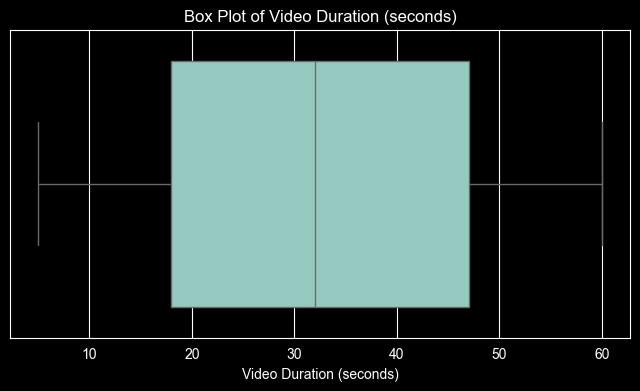

In [10]:
# Create a boxplot to visualize distribution of `video_duration_sec`
plt.figure(figsize=(8, 4))
sns.boxplot(x=data['video_duration_sec'])
plt.title("Box Plot of Video Duration (seconds)")
plt.xlabel("Video Duration (seconds)")
plt.show()

Create a histogram of the values in the `video_duration_sec` column to further explore the distribution of this variable.

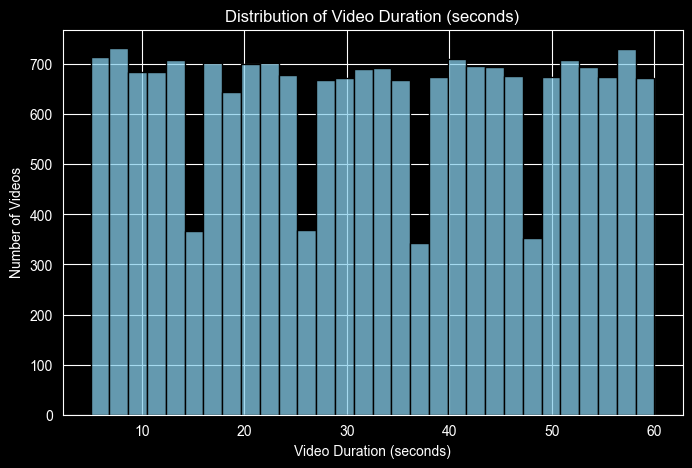

In [11]:
# Create a histogram
plt.figure(figsize=(8, 5))
sns.histplot(data['video_duration_sec'], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Video Duration (seconds)")
plt.xlabel("Video Duration (seconds)")
plt.ylabel("Number of Videos")
plt.show()

**Question:** What do you notice about the duration and distribution of the videos?

**Answer:** The video durations range approximately from 5 to 60 seconds, indicating a likely platform-imposed cap at 60 seconds. The distribution appears relatively uniform across this range, suggesting that creators utilize a wide variety of video lengths. Unlike engagement metrics, the duration variable does not appear heavily skewed and does not exhibit extreme outliers. Overall, video length is evenly distributed rather than concentrated around a specific duration.

#### **video_view_count**

Create a box plot to examine the spread of values in the `video_view_count` column.

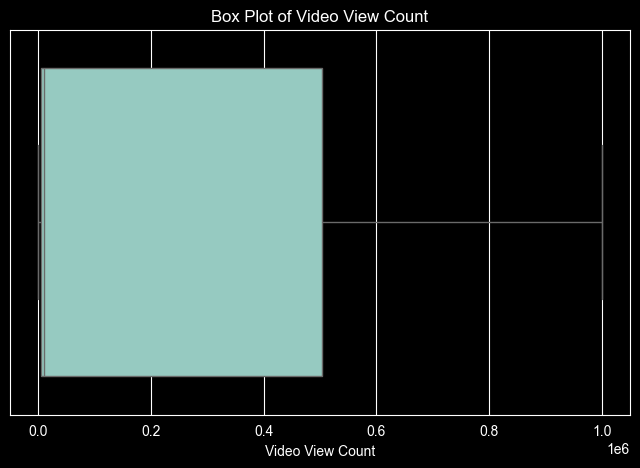

In [12]:
# Create a boxplot to visualize distribution of `video_view_count`
plt.figure(figsize=(8, 5))
sns.boxplot(x=data['video_view_count'])
plt.title("Box Plot of Video View Count")
plt.xlabel("Video View Count")
plt.show()

Create a histogram of the values in the `video_view_count` column to further explore the distribution of this variable.

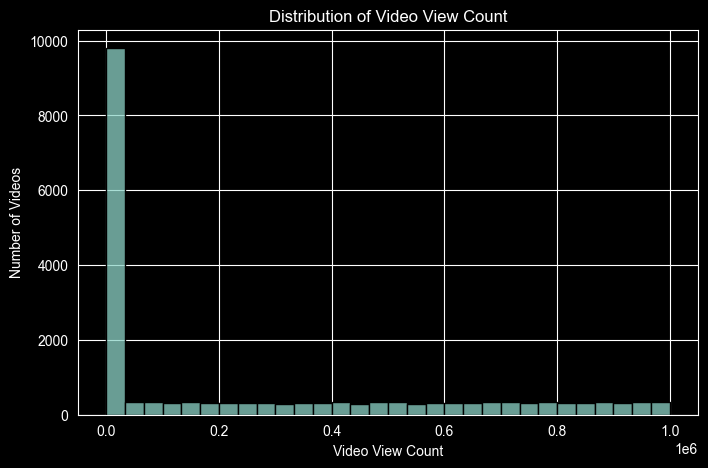

In [13]:
# Create a histogram
plt.figure(figsize=(8, 5))
sns.histplot(data['video_view_count'], bins=30, edgecolor='black')
plt.title("Distribution of Video View Count")
plt.xlabel("Video View Count")
plt.ylabel("Number of Videos")
plt.show()

**Question:** What do you notice about the distribution of this variable?

**Answer:** The distribution of video_view_count is highly right-skewed. Most videos have relatively low view counts, while a small number of videos achieve extremely high views. The box plot shows that the median view count is concentrated toward the lower end of the range, and the histogram confirms the presence of a long right tail. This indicates that engagement is unevenly distributed, with viral videos significantly influencing overall statistics.

#### **video_like_count**

Create a box plot to examine the spread of values in the `video_like_count` column.

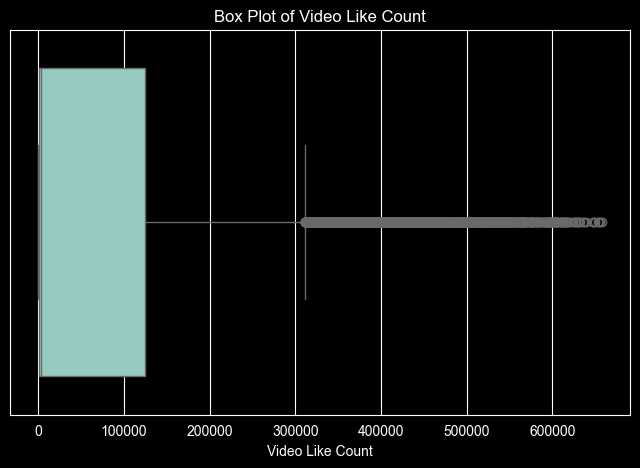

In [14]:
# Create a boxplot to visualize distribution of `video_like_count`
plt.figure(figsize=(8, 5))
sns.boxplot(x=data['video_like_count'])
plt.title("Box Plot of Video Like Count")
plt.xlabel("Video Like Count")
plt.show()

Create a histogram of the values in the `video_like_count` column to further explore the distribution of this variable.

Text(0, 0.5, 'Number of Videos')

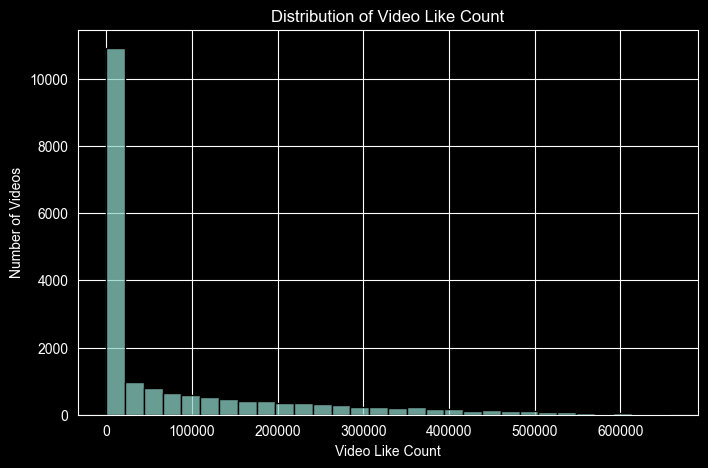

In [15]:
# Create a histogram
plt.figure(figsize=(8, 5))
sns.histplot(data['video_like_count'], bins=30, edgecolor='black')
plt.title("Distribution of Video Like Count")
plt.xlabel("Video Like Count")
plt.ylabel("Number of Videos")

**Question:** What do you notice about the distribution of this variable?

**Answer:** The distribution of video_like_count is highly right-skewed. Most videos receive relatively low numbers of likes, while a small number achieve extremely high engagement. The box plot reveals numerous high-value outliers, and the histogram confirms the presence of a long right tail. This indicates that likes are unevenly distributed across videos, with viral content significantly influencing overall engagement metrics.

#### **video_comment_count**

Create a box plot to examine the spread of values in the `video_comment_count` column.

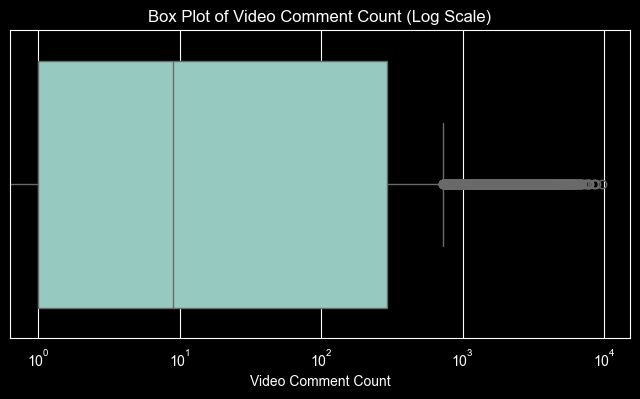

In [16]:
# Create a boxplot to visualize distribution of `video_comment_count`
plt.figure(figsize=(8, 4))
sns.boxplot(x=data['video_comment_count'])
plt.xscale('log')
plt.title('Box Plot of Video Comment Count (Log Scale)')
plt.xlabel('Video Comment Count')
plt.show()

Create a histogram of the values in the `video_comment_count` column to further explore the distribution of this variable.

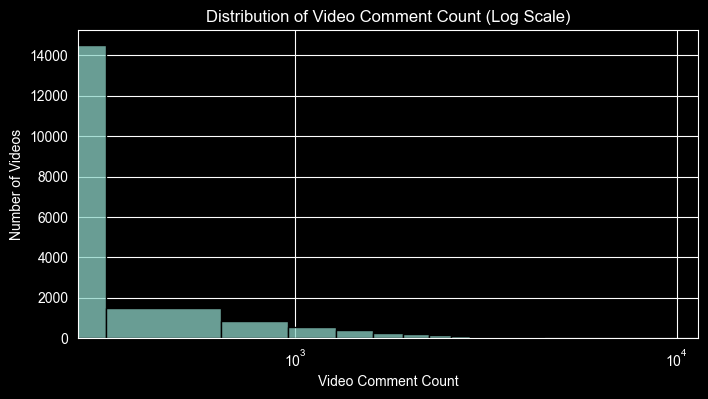

In [17]:
# Create a histogram
plt.figure(figsize=(8, 4))
sns.histplot(data['video_comment_count'], bins=30, edgecolor='black')
plt.xscale('log')
plt.title('Distribution of Video Comment Count (Log Scale)')
plt.xlabel('Video Comment Count')
plt.ylabel('Number of Videos')
plt.show()

**Question:** What do you notice about the distribution of this variable?

**Answer:** The distribution of video_comment_count is heavily right-skewed, even after applying a log scale. Most videos receive relatively low numbers of comments, while a small number generate substantially higher interaction. The box plot shows a large concentration of values near the lower end, with multiple extreme outliers extending far to the right. This suggests that commenting behavior is unevenly distributed, with a small subset of highly engaging videos driving a disproportionate share of total comments

#### **video_share_count**

Create a box plot to examine the spread of values in the `video_share_count` column.

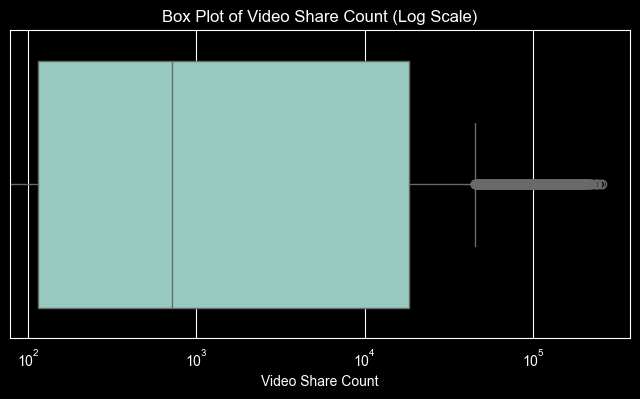

In [18]:
# Create a boxplot to visualize distribution of `video_share_count`
plt.figure(figsize=(8, 4))
sns.boxplot(x=data['video_share_count'])
plt.xscale('log')
plt.title('Box Plot of Video Share Count (Log Scale)')
plt.xlabel('Video Share Count')
plt.show()

*Create* a histogram of the values in the `video_share_count` column to further explore the distribution of this variable.

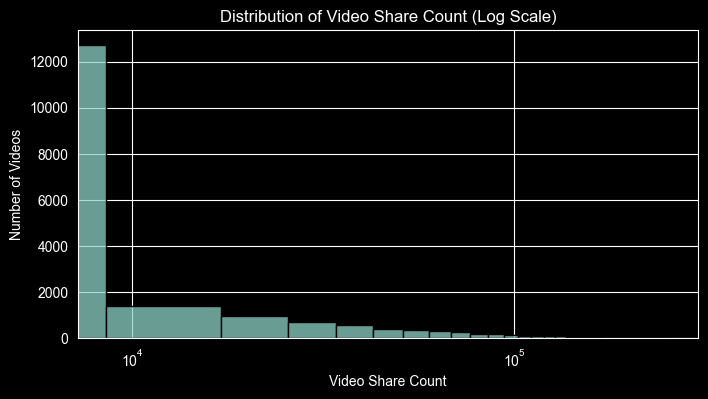

In [19]:
# Create a histogram
plt.figure(figsize=(8, 4))
sns.histplot(data['video_share_count'], bins=30, edgecolor='black')
plt.xscale('log')
plt.title('Distribution of Video Share Count (Log Scale)')
plt.xlabel('Video Share Count')
plt.ylabel('Number of Videos')
plt.show()

**Question:** What do you notice about the distribution of this variable?

**Answer:** The video_share_count variable also exhibits strong right skewness. The majority of videos accumulate moderate share counts, while a limited number reach exceptionally high values. The presence of a long right tail in the histogram indicates that viral content significantly influences share metrics. Compared to comments, shares appear to have a slightly wider overall spread, suggesting that content virality may drive sharing behavior more strongly than commenting behavior.

#### **video_download_count**

Create a box plot to examine the spread of values in the `video_download_count` column.

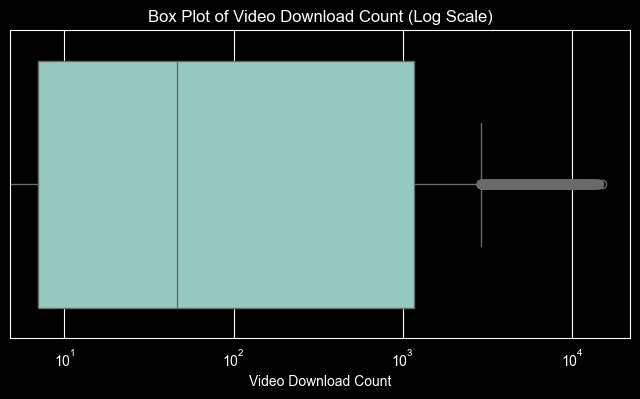

In [20]:
# Create a boxplot to visualize distribution of `video_download_count`
plt.figure(figsize=(8, 4))
sns.boxplot(x=data['video_download_count'])
plt.xscale('log')
plt.title('Box Plot of Video Download Count (Log Scale)')
plt.xlabel('Video Download Count')
plt.show()

Create a histogram of the values in the `video_download_count` column to further explore the distribution of this variable.

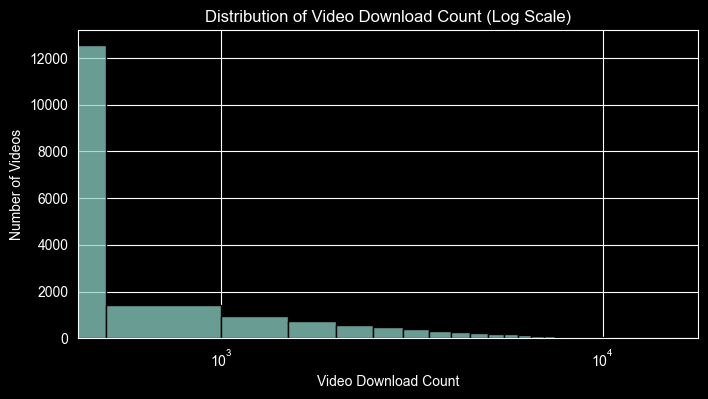

In [21]:
# Create a histogram
plt.figure(figsize=(8, 4))
sns.histplot(data['video_download_count'], bins=30, edgecolor='black')
plt.xscale('log')
plt.title('Distribution of Video Download Count (Log Scale)')
plt.xlabel('Video Download Count')
plt.ylabel('Number of Videos')
plt.show()

**Question:** What do you notice about the distribution of this variable?

**Answer:** The distribution of video_download_count follows a similar right-skewed pattern. Most videos have relatively low download counts, with a small number showing extremely high values. The box plot reveals numerous upper-end outliers, indicating that downloads, like other engagement metrics, are concentrated among a small group of high-performing videos. This pattern reinforces the idea that user engagement is highly unequal across content, with viral videos disproportionately contributing to overall interaction metrics.

#### **Claim status by verification status**

Now, create a histogram with four bars: one for each combination of claim status and verification status.

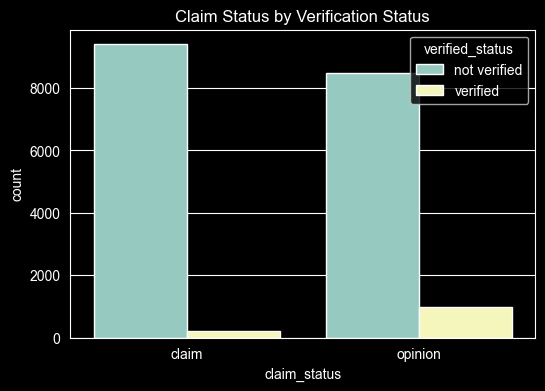

In [22]:
# Create a histogram
plt.figure(figsize=(6,4))
sns.countplot(
    data=data,
    x='claim_status',
    hue='verified_status'
)
plt.title('Claim Status by Verification Status')
plt.show()

**Question:** What do you notice about the number of verified users compared to unverified? And how does that affect their likelihood to post opinions?

**Answer:** Verified users are WAY fewer than unverified.
Unverified dominate everything.
Also seems like opinions are more common among unverified users.
Verified users look more balanced or slightly claim-heavy.
Basically — platform is mostly unverified creators.

#### **Claim status by author ban status**

The previous course used a `groupby()` statement to examine the count of each claim status for each author ban status. Now, use a histogram to communicate the same information.

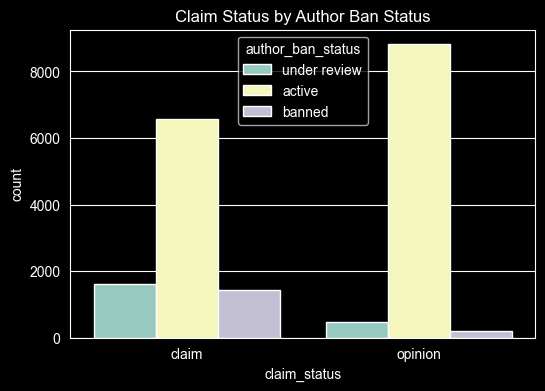

In [31]:
# Create a histogram
plt.figure(figsize=(6,4))
sns.countplot(
    data=data,
    x='claim_status',
    hue='author_ban_status'
)
plt.title('Claim Status by Author Ban Status')
plt.show()


**Question:** What do you notice about the number of active authors compared to banned authors for both claims and opinions?

**Answer:** Active authors massively outnumber banned ones. Like, they are not even close. Both claims and opinions mostly come from active users. Banned authors are just a tiny fraction. Banning is rare overall.

#### **Median view counts by ban status**

Create a bar plot with three bars: one for each author ban status. The height of each bar should correspond with the median number of views for all videos with that author ban status.

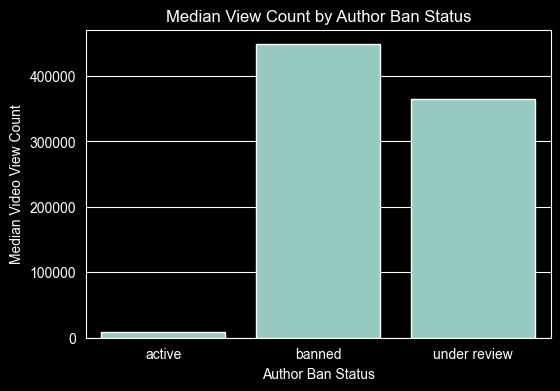

In [34]:
# Create a bar plot
median_views = data.groupby('author_ban_status')['video_view_count'].median().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(
    data=median_views,
    x='author_ban_status',
    y='video_view_count'
)
plt.title('Median View Count by Author Ban Status')
plt.xlabel('Author Ban Status')
plt.ylabel('Median Video View Count')
plt.show()

**Question:** What do you notice about the median view counts for non-active authors compared to that of active authors? Based on that insight, what variable might be a good indicator of claim status?

**Answer:** Active authors have lowest median views. Banned authors actually have the highest median views. Under review authors are also pretty high. So higher engagement might be linked to higher risk content. Maybe viral claim-type content gets flagged more often. This suggests view count could be a strong signal for claim status. High engagement videos might be more likely to be cliams

#### **Total views by claim status**

Create a pie graph that depicts the proportions of total views for claim videos and total views for opinion videos.

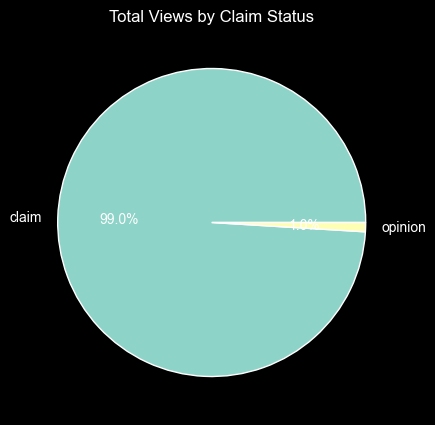

In [35]:
# Create a pie graph
total_views = data.groupby('claim_status')['video_view_count'].sum()
plt.figure(figsize=(5,5))
plt.pie(total_views,
        labels= total_views.index,
        autopct = '%1.1f%%')
plt.title('Total Views by Claim Status')
plt.show()


**Question:** What do you notice about the overall view count for claim status?

**Answer:** Claims dominate total views, not even subtly. Even if counts are similar, claims pull more engagement overall. They seem to drive the virality.

### **Task 4. Determine outliers**

When building predictive models, the presence of outliers can be problematic. For example, if you were trying to predict the view count of a particular video, videos with extremely high view counts might introduce bias to a model. Also, some outliers might indicate problems with how data was captured or recorded.

The ultimate objective of the TikTok project is to build a model that predicts whether a video is a claim or opinion. The analysis you've performed indicates that a video's engagement level is strongly correlated with its claim status. There's no reason to believe that any of the values in the TikTok data are erroneously captured, and they align with expectation of how social media works: a very small proportion of videos get super high engagement levels. That's the nature of viral content.

Nonetheless, it's good practice to get a sense of just how many of your data points could be considered outliers. The definition of an outlier can change based on the details of your project, and it helps to have domain expertise to decide a threshold. You've learned that a common way to determine outliers in a normal distribution is to calculate the interquartile range (IQR) and set a threshold that is 1.5 * IQR above the 3rd quartile.

In this TikTok dataset, the values for the count variables are not normally distributed. They are heavily skewed to the right. One way of modifying the outlier threshold is by calculating the **median** value for each variable and then adding 1.5 * IQR. This results in a threshold that is, in this case, much lower than it would be if you used the 3rd quartile.

Write a for loop that iterates over the column names of each count variable. For each iteration:
1. Calculate the IQR of the column
2. Calculate the median of the column
3. Calculate the outlier threshold (median + 1.5 * IQR)
4. Calculate the numer of videos with a count in that column that exceeds the outlier threshold
5. Print "Number of outliers, {column name}: {outlier count}"

```
Example:
Number of outliers, video_view_count: ___
Number of outliers, video_like_count: ___
Number of outliers, video_share_count: ___
Number of outliers, video_download_count: ___
Number of outliers, video_comment_count: ___
```

In [37]:
count_columns = [
    'video_view_count',
    'video_like_count',
    'video_share_count',
    'video_download_count',
    'video_comment_count'
]

for col in count_columns:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    median = data[col].median()

    threshold = median + 1.5 * IQR

    outliers = data[data[col] > threshold].shape[0]

    print(f"Number of outliers, {col}: {outliers}")


Number of outliers, video_view_count: 2343
Number of outliers, video_like_count: 3468
Number of outliers, video_share_count: 3732
Number of outliers, video_download_count: 3733
Number of outliers, video_comment_count: 3882


#### **Scatterplot**

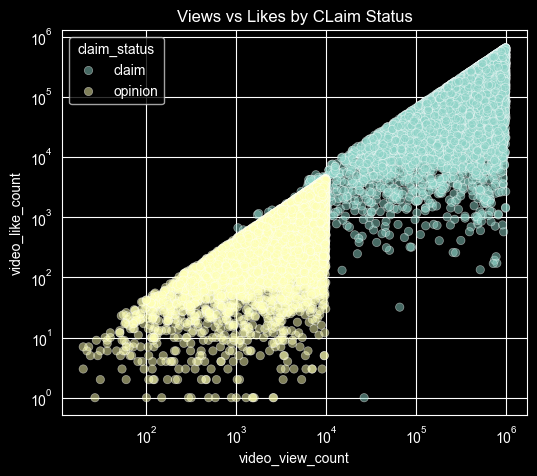

In [38]:
# Create a scatterplot of `video_view_count` versus `video_like_count` according to 'claim_status'
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=data,
    x='video_view_count',
    y='video_like_count',
    hue='claim_status',
    alpha=0.5
)
plt.xscale('log')
plt.yscale('log')
plt.title('Views vs Likes by CLaim Status')
plt.show()


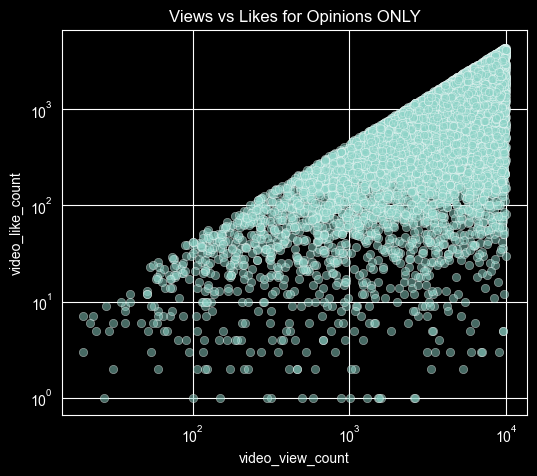

In [40]:
# Create a scatterplot of ``video_view_count` versus `video_like_count` for opinions only
plt.figure(figsize=(6,5))
opinions = data[data['claim_status']=='opinion']
sns.scatterplot(
    data=opinions,
    x='video_view_count',
    y='video_like_count',
    alpha=0.5
)
plt.xscale('log')
plt.yscale('log')
plt.title('Views vs Likes for Opinions ONLY')
plt.show()

<img src="images/Execute.png" width="100" height="100" align=left>

## **PACE: Execute**

Consider the questions in your PACE Strategy Document to reflect on the Execute stage.

### **Task 5a. Results and evaluation**

Having built visualizations in Tableau and in Python, what have you learned about the dataset? What other questions have your visualizations uncovered that you should pursue?

***Pro tip:*** Put yourself in your client's perspective, what would they want to know?

Use the following code cells to pursue any additional EDA. Also use the space to make sure your visualizations are clean, easily understandable, and accessible.

***Ask yourself:*** Did you consider color, contrast, emphasis, and labeling?


==> ENTER YOUR RESPONSE HERE

I have learned engagement is insanely skewed.
Small % of videos dominate everything.

Claims consistently show higher views, likes, shares.
Engagement metrics are strongly tied to claim status.

Most creators are unverified and active.

My other questions are —
Are claims emotionally triggering more engagement?
Are banned authors posting more claims?
Is engagement the main predictive feature?

My client would likely want to know —
What makes a video likely to be a claim?
Can we predict misinformation early using engagement spikes?
Is there a pattern before something goes viral?


### **Task 5b. Conclusion**
*Make it professional and presentable*

You have visualized the data you need to share with the director now. Remember, the goal of a data visualization is for an audience member to glean the information on the chart in mere seconds.

*Questions to ask yourself for reflection:*
Why is it important to conduct Exploratory Data Analysis? What other visuals could you create?


EDA is important because it shows patterns before modeling.
Without it, we’d blindly build models on skewed data.

Visualizations helped me understand how unequal engagement is.
Also confirmed claim videos behave differently than opinions.

Could also create:
– Engagement ratio plots
– Correlation heatmap
– Distribution comparison by verification status

Main takeaway:
Engagement is the strongest signal so far.
